
> Imports
---



Using Colab cache for faster access to the 'ames-housing-dataset' dataset.


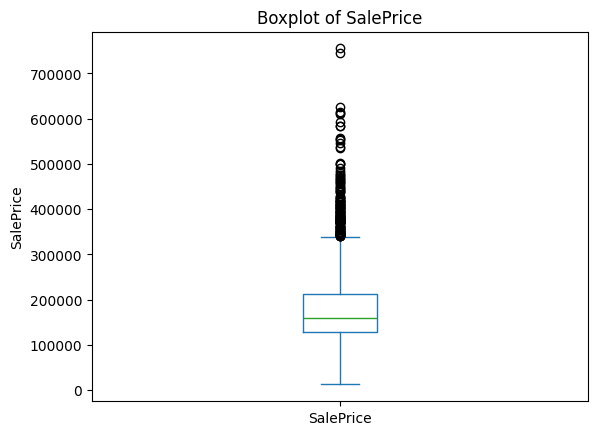

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from cleaning_01 import get_data, clean_data

data = get_data()
cleaned_df, dup_count = clean_data(data)

> Mean + Std

---





```
I computed mean and std manually.
```



In [ ]:
def compute_mean_std(df):

    x = df["SalePrice"].values

    mean = np.sum(x) / len(x)
    std = np.sqrt(np.sum((x - mean)**2) / len(x))

    print("Mean:", mean)
    print("Std:", std)


> Standardization

---





```
I applied z-score manually
```



In [ ]:
def manual_standardization(df):

    x = df["Gr Liv Area"].values

    mean = np.mean(x)
    std = np.std(x)

    z = (x - mean) / std

    print("Manual mean:", np.mean(z))
    print("Manual std:", np.std(z))

> StandardScaler

---





```
I compared with StandardScaler.
```



In [ ]:
from sklearn.preprocessing import StandardScaler

def compare_scaler(df):

    scaler = StandardScaler()

    scaled = scaler.fit_transform(df[["Gr Liv Area"]])

    print("Scaler mean:", scaled.mean())
    print("Scaler std:", scaled.std())

> Cosine Similarity

---





```
I measured similarity between records.
```



In [ ]:
def cosine_similarity_calc(df):

    numeric_df = df.select_dtypes(include = np.number)

    high = numeric_df.loc[df["SalePrice"].idxmax()].values
    low = numeric_df.loc[df["SalePrice"].idxmin()].values

    cos_sim = np.dot(high, low) / (np.linalg.norm(high) * np.linalg.norm(low))

    print("Cosine similarity:", cos_sim)

    return cos_sim

> Probability

---





```
I estimated probability based on quality.
```



In [ ]:
def probability_calc(df):

    threshold = df["SalePrice"].quantile(0.75)

    high_quality = df[df["Overall Qual"] >= 7]

    prob = (high_quality["SalePrice"] > threshold).mean()

    print("Probability:", prob)

    return prob

> Run Math

---



In [ ]:
def run_math(df):

    compute_mean_std(df)
    manual_standardization(df)
    compare_scaler(df)
    cosine_similarity_calc(df)
    probability_calc(df)

In [ ]:
run_math(cleaned_df)

Mean: 179956.70481228668
Std: 76061.61121141634
Manual mean: 3.637590797406656e-17
Manual std: 1.0
Scaler mean: 3.637590797406656e-17
Scaler std: 1.0
Cosine similarity: 0.9999996328852537
Probability: 0.5990825688073395
